# 02 — Tiền xử lý và Feature Engineering

Mục tiêu là tạo feature có thể sử dụng tại thời điểm ra quyết định, đồng thời chứng minh mọi phép fit thống kê chỉ học từ train.

In [1]:
from pathlib import Path
import os, sys, json, warnings

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.environ["MPLCONFIGDIR"] = str(ROOT / ".matplotlib")
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")

TRAIN_PATH = ROOT / "data" / "train.csv"
TEST_PATH = ROOT / "data" / "test.csv"
TARGET = "Loan Sanction Amount (USD)"
REQUEST = "Loan Amount Request (USD)"
RANDOM_STATE = 42

df_raw = pd.read_csv(TRAIN_PATH)
df_external = pd.read_csv(TEST_PATH)
print(f"Train: {df_raw.shape[0]:,} dòng x {df_raw.shape[1]} cột")
print(f"Test ngoài: {df_external.shape[0]:,} dòng x {df_external.shape[1]} cột")

Train: 30,000 dòng x 24 cột
Test ngoài: 20,000 dòng x 23 cột


In [2]:
SENTINEL = -999
DROP_COLUMNS = ["Customer ID", "Name", "Property ID", "Gender"]
BASE_FEATURES = [
    "Age", "Income (USD)", "Income Stability", "Profession",
    "Type of Employment", "Location", REQUEST,
    "Current Loan Expenses (USD)", "Expense Type 1", "Expense Type 2",
    "Dependents", "Credit Score", "No. of Defaults",
    "Has Active Credit Card", "Property Age", "Property Type",
    "Property Location", "Co-Applicant", "Property Price",
]
ENGINEERED_FEATURES = [
    "RequestToIncome", "RequestToProperty", "ExpenseToIncome",
    "IncomePerDependent", "PropertyEquityProxy", "CreditIncomeInteraction",
    "CreditRequestInteraction", "AgeIncomeInteraction",
]

def normalize_missing(df):
    out = df.copy()
    out = out.replace(SENTINEL, np.nan)
    return out

def add_business_features(df):
    out = normalize_missing(df)
    eps = 1e-6
    income = out["Income (USD)"].clip(lower=eps)
    request = out[REQUEST].clip(lower=0)
    property_price = out["Property Price"].clip(lower=eps)
    expenses = out["Current Loan Expenses (USD)"].clip(lower=0)
    dependents = out["Dependents"].clip(lower=0).fillna(0)
    credit = out["Credit Score"]

    out["RequestToIncome"] = request / income
    out["RequestToProperty"] = request / property_price
    out["ExpenseToIncome"] = expenses / income
    out["IncomePerDependent"] = income / (dependents + 1)
    out["PropertyEquityProxy"] = property_price - request
    out["CreditIncomeInteraction"] = credit * np.log1p(income)
    out["CreditRequestInteraction"] = credit / (request + 1) * 1000
    out["AgeIncomeInteraction"] = out["Age"] * np.log1p(income)
    return out

def modeling_frame(df):
    out = add_business_features(df)
    columns = [c for c in BASE_FEATURES + ENGINEERED_FEATURES if c in out.columns]
    return out[columns].copy()

def valid_regression_rows(df):
    target = pd.to_numeric(df[TARGET], errors="coerce")
    return target.notna() & (target > 0)

In [3]:
from sklearn.model_selection import train_test_split

def quantile_labels(y, q=10):
    return pd.qcut(y.rank(method="first"), q=q, labels=False, duplicates="drop")

def make_splits(df, random_state=RANDOM_STATE):
    clean = normalize_missing(df.loc[valid_regression_rows(df)].copy())
    train_val, test = train_test_split(
        clean,
        test_size=0.15,
        random_state=random_state,
        stratify=quantile_labels(clean[TARGET]),
    )
    train, val = train_test_split(
        train_val,
        test_size=0.1764705882,
        random_state=random_state,
        stratify=quantile_labels(train_val[TARGET]),
    )
    return train.copy(), val.copy(), test.copy()

## 1. Làm sạch target và chia dữ liệu trước khi fit

In [4]:
train_df, val_df, test_df = make_splits(df_raw)
print(f"Train: {len(train_df):,} | Validation: {len(val_df):,} | Test nội bộ: {len(test_df):,}")
print(f"Tổng: {len(train_df) + len(val_df) + len(test_df):,}")

split_summary = pd.DataFrame({
    "train": train_df[TARGET].describe(),
    "validation": val_df[TARGET].describe(),
    "test": test_df[TARGET].describe(),
})
display(split_summary)

Train: 15,019 | Validation: 3,219 | Test nội bộ: 3,219
Tổng: 21,457


,train,validation,test
count,"15,019.000","3,219.000","3,219.000"
mean,"65,892.050","65,810.642","65,902.453"
std,"44,867.912","44,836.191","44,851.746"
min,"4,183.490","4,023.180","4,319.610"
25%,"30,376.185","30,199.935","29,984.600"
50%,"55,196.670","55,182.140","55,233.680"
75%,"89,303.870","88,657.960","88,913.130"
max,"481,907.320","293,150.140","323,233.310"


## 2. Chuẩn hóa sentinel và xây feature business

In [5]:
X_train = modeling_frame(train_df)
X_val = modeling_frame(val_df)
X_test = modeling_frame(test_df)
y_train, y_val, y_test = train_df[TARGET], val_df[TARGET], test_df[TARGET]

print(f"Số feature sau engineering: {X_train.shape[1]}")
print("Các feature mới:")
engineered = [c for c in X_train.columns if c not in df_raw.columns]
print(engineered)

assert not np.isinf(X_train.select_dtypes(include=np.number)).any().any()
assert TARGET not in X_train.columns
assert not set(DROP_COLUMNS).intersection(X_train.columns)
print("Kiểm tra leakage, identifier và giá trị vô cực: đạt")

Số feature sau engineering: 27
Các feature mới:
['RequestToIncome', 'RequestToProperty', 'ExpenseToIncome', 'IncomePerDependent', 'PropertyEquityProxy', 'CreditIncomeInteraction', 'CreditRequestInteraction', 'AgeIncomeInteraction']
Kiểm tra leakage, identifier và giá trị vô cực: đạt


In [6]:
feature_quality = pd.DataFrame({
    "dtype": X_train.dtypes.astype(str),
    "missing_train": X_train.isna().sum(),
    "missing_val": X_val.isna().sum(),
    "missing_test": X_test.isna().sum(),
    "n_unique_train": X_train.nunique(dropna=False),
}).sort_values("missing_train", ascending=False)
display(feature_quality)

,dtype,missing_train,missing_val,missing_test,n_unique_train
Type of Employment,object,3910,857,829,19
CreditIncomeInteraction,float64,3419,742,758,11600
Property Age,float64,2861,614,624,11922
ExpenseToIncome,float64,2852,608,622,12168
IncomePerDependent,float64,2694,582,592,12200
AgeIncomeInteraction,float64,2694,582,592,12313
RequestToIncome,float64,2694,582,592,12326
Income (USD),float64,2694,582,592,12083
Dependents,float64,1463,320,292,10
Income Stability,object,1014,210,218,3


## 3. Fit preprocessing chỉ trên train

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score,
    mean_squared_log_error,
)

def build_preprocessor(X, scale_numeric=False):
    numeric = X.select_dtypes(include=np.number).columns.tolist()
    categorical = X.select_dtypes(exclude=np.number).columns.tolist()
    numeric_steps = [("imputer", SimpleImputer(strategy="median", add_indicator=True))]
    if scale_numeric:
        numeric_steps.append(("scaler", RobustScaler()))
    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", Pipeline(numeric_steps), numeric),
            (
                "categorical",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                ]),
                categorical,
            ),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    return preprocessor

def regression_metrics(y_true, y_pred, requested=None):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    abs_error = np.abs(y_true - y_pred)
    denom = np.maximum(np.abs(y_true), 1.0)
    result = {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": root_mean_squared_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
        "rmsle": np.sqrt(mean_squared_log_error(np.maximum(y_true, 0), np.maximum(y_pred, 0))),
        "wape": abs_error.sum() / np.abs(y_true).sum(),
        "within_10pct": np.mean(abs_error / denom <= 0.10),
        "within_20pct": np.mean(abs_error / denom <= 0.20),
        "mean_signed_error": np.mean(y_pred - y_true),
        "over_rate": np.mean(y_pred > y_true),
    }
    if requested is not None:
        requested = np.asarray(requested, dtype=float)
        result["above_request_rate"] = np.mean(y_pred > requested)
    return result

def apply_policy(raw_prediction, requested, property_price=None, max_ltv=0.90):
    prediction = np.maximum(np.asarray(raw_prediction, dtype=float), 0)
    prediction = np.minimum(prediction, np.asarray(requested, dtype=float))
    if property_price is not None:
        valid_property = np.asarray(property_price, dtype=float)
        cap = np.where(np.isfinite(valid_property) & (valid_property > 0), valid_property * max_ltv, np.inf)
        prediction = np.minimum(prediction, cap)
    return prediction

In [8]:
preprocessor = build_preprocessor(X_train, scale_numeric=True)
Xt_train = preprocessor.fit_transform(X_train)
Xt_val = preprocessor.transform(X_val)
Xt_test = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

print(f"Ma trận train sau preprocessing: {Xt_train.shape}")
print(f"Ma trận validation: {Xt_val.shape}")
print(f"Ma trận test: {Xt_test.shape}")
print(f"NaN sau preprocessing: {np.isnan(Xt_train).sum():,}")
print("Preprocessor chỉ fit trên X_train; validation/test chỉ gọi transform.")

Ma trận train sau preprocessing: (15019, 73)
Ma trận validation: (3219, 73)
Ma trận test: (3219, 73)
NaN sau preprocessing: 0
Preprocessor chỉ fit trên X_train; validation/test chỉ gọi transform.


## 4. Kiểm tra sức giải thích và đa cộng tuyến

,Spearman với target
Loan Amount Request (USD),0.994
CreditRequestInteraction,-0.978
Property Price,0.969
Current Loan Expenses (USD),0.815
PropertyEquityProxy,0.765
RequestToIncome,0.744
ExpenseToIncome,0.449
Property Age,0.406
Income (USD),0.406
CreditIncomeInteraction,0.387


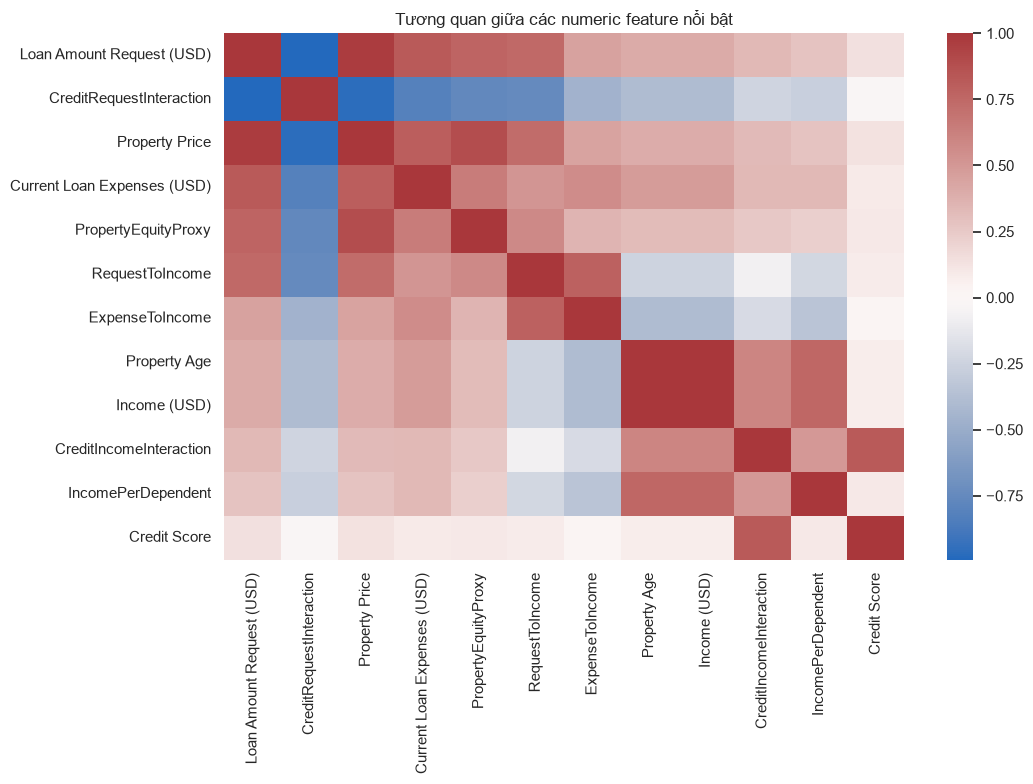

In [9]:
numeric_engineered = X_train.select_dtypes(include=np.number).copy()
numeric_engineered[TARGET] = y_train.values
corr_target = numeric_engineered.corr(method="spearman")[TARGET].drop(TARGET).sort_values(key=np.abs, ascending=False)
display(corr_target.to_frame("Spearman với target"))

top_numeric = corr_target.head(12).index
plt.figure(figsize=(11, 8))
sns.heatmap(numeric_engineered[list(top_numeric)].corr(method="spearman"), cmap="vlag", center=0)
plt.title("Tương quan giữa các numeric feature nổi bật")
plt.tight_layout()
plt.show()

In [10]:
from sklearn.feature_selection import mutual_info_regression

numeric_imputed = pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(X_train.select_dtypes(include=np.number)),
    columns=X_train.select_dtypes(include=np.number).columns,
    index=X_train.index,
)
mi = pd.Series(
    mutual_info_regression(numeric_imputed, y_train, random_state=RANDOM_STATE),
    index=numeric_imputed.columns,
).sort_values(ascending=False)
display(mi.to_frame("Mutual information"))

,Mutual information
Loan Amount Request (USD),5.822
CreditRequestInteraction,1.628
Property Price,1.442
Current Loan Expenses (USD),0.672
PropertyEquityProxy,0.612
RequestToIncome,0.347
ExpenseToIncome,0.100
Income (USD),0.083
Property Age,0.082
CreditIncomeInteraction,0.067


## 5. Kết luận feature engineering

In [11]:
top_corr = corr_target.index[0]
top_mi = mi.index[0]
display(Markdown(f"""
### Kết luận

- Dữ liệu được chia 70% train, 15% validation và 15% test nội bộ trước mọi phép fit.
- Feature có tương quan đơn biến mạnh nhất với target là **{top_corr}**; feature có mutual information cao nhất là **{top_mi}**.
- `Loan Amount Request (USD)` và các tỷ lệ dẫn xuất từ nó nhiều khả năng chi phối mô hình. Đây là tín hiệu đúng nghiệp vụ nhưng cũng cho thấy model đang học policy lịch sử.
- Identifier và `Gender` đã bị loại khỏi production feature set. `Gender` sẽ quay lại ở notebook diễn giải chỉ để audit sai số.
- Pipeline imputation và encoding xử lý được missing/unseen categories mà không học thông tin từ validation hoặc test.
"""))


### Kết luận

- Dữ liệu được chia 70% train, 15% validation và 15% test nội bộ trước mọi phép fit.
- Feature có tương quan đơn biến mạnh nhất với target là **Loan Amount Request (USD)**; feature có mutual information cao nhất là **Loan Amount Request (USD)**.
- `Loan Amount Request (USD)` và các tỷ lệ dẫn xuất từ nó nhiều khả năng chi phối mô hình. Đây là tín hiệu đúng nghiệp vụ nhưng cũng cho thấy model đang học policy lịch sử.
- Identifier và `Gender` đã bị loại khỏi production feature set. `Gender` sẽ quay lại ở notebook diễn giải chỉ để audit sai số.
- Pipeline imputation và encoding xử lý được missing/unseen categories mà không học thông tin từ validation hoặc test.
